# FlashEats — Class 5 Investigation (Local Solved)

Solved locally against the submission repository. This notebook covers source discovery, late-delivery analysis, customer evidence, reliable API retrieval, and event observability.

In [1]:
from pathlib import Path
import json, sqlite3, sys, time, subprocess
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_root():
    candidates = [Path.cwd(), *Path.cwd().parents, Path(r"C:\Users\piyus\Downloads\FDE\flasheats-assignment-submission")]
    for p in candidates:
        if (p / "data" / "raw" / "sqlite" / "flasheats.db").exists():
            return p
    raise FileNotFoundError("Could not find the submission repo. Open this notebook from the submission folder or update ROOT.")

ROOT = find_root()
DB = ROOT / "data" / "raw" / "sqlite" / "flasheats.db"
DATA = ROOT / "data" / "raw" / "files"
OUT = ROOT / "outputs" / "classroom_challenges"
OUT.mkdir(parents=True, exist_ok=True)
con = sqlite3.connect(DB)
orders = pd.read_sql("SELECT * FROM orders", con)
orders["created_at"] = pd.to_datetime(orders["created_at"], errors="coerce")
orders["promised_eta"] = pd.to_datetime(orders["promised_eta"], errors="coerce")
orders["pickup_at"] = pd.to_datetime(orders["pickup_at"], errors="coerce")
orders["actual_delivery_at"] = pd.to_datetime(orders["actual_delivery_at"], errors="coerce")
orders = orders.drop_duplicates("order_id", keep="first")
outcomes = pd.read_csv(DATA / "order_outcomes.csv")
events = pd.read_csv(DATA / "order_events.csv")
tickets = pd.read_csv(DATA / "support_tickets.csv")
actions = pd.read_csv(DATA / "customer_app_actions.csv")
interventions = pd.read_csv(DATA / "order_interventions.csv")
restaurant_status = pd.read_csv(DATA / "restaurant_status.csv")
driver_events = json.loads((DATA / "driver_events.json").read_text(encoding="utf-8"))


## Challenge 1 — Late-delivery problem

Definition used here: a delivered order with non-null promised and actual delivery timestamps is late when actual delivery is after the promised ETA. Cancelled and timestamp-missing orders are excluded from the denominator.

In [2]:
analysis = orders[orders["final_status"].astype(str).str.lower().eq("delivered")].copy()
analysis["delay_min"] = (analysis["actual_delivery_at"] - analysis["promised_eta"]).dt.total_seconds() / 60
measurable = analysis.dropna(subset=["promised_eta", "actual_delivery_at"])
late = measurable[measurable["delay_min"] > 0]
print({"measurable_deliveries": len(measurable), "late_count": len(late), "late_rate_pct": round(late.shape[0] / len(measurable) * 100, 2), "median_lateness_min": round(late["delay_min"].median(), 2)})
display(late.nlargest(10, "delay_min")[['order_id','promised_eta','actual_delivery_at','delay_min']])
print("Quality issues:", {"duplicate_order_ids": int(orders["order_id"].duplicated().sum()), "delivered_missing_actual": int((analysis["actual_delivery_at"].isna()).sum()), "promised_before_created": int((analysis["promised_eta"] < analysis["created_at"]).sum())})

{'measurable_deliveries': 754, 'late_count': 430, 'late_rate_pct': 57.03, 'median_lateness_min': np.float64(8.45)}


,order_id,promised_eta,actual_delivery_at,delay_min
103,O00104,2026-08-09 22:09:00,2026-08-09 23:36:20.740161,87.345669
101,O00102,2026-08-11 16:31:00,2026-08-11 17:57:17.661772,86.294363
100,O00101,2026-08-24 20:49:00,2026-08-24 22:14:30.685278,85.511421
102,O00103,2026-08-22 20:01:00,2026-08-22 21:10:17.342305,69.289038
472,O00473,2026-08-14 20:17:48,2026-08-14 21:04:00.769224,46.212820
193,O00194,2026-08-11 19:01:48,2026-08-11 19:40:08.111510,38.335192
1311,O01312,2026-08-14 20:17:36,2026-08-14 20:54:36.321890,37.005365
1402,O01403,2026-08-24 18:47:36,2026-08-24 19:24:32.047659,36.934128
459,O00460,2026-08-12 17:52:24,2026-08-12 18:29:16.970368,36.882839
496,O00497,2026-08-13 20:44:18,2026-08-13 21:16:04.765594,31.779427


Quality issues: {'duplicate_order_ids': 0, 'delivered_missing_actual': 37, 'promised_before_created': 4}


## Challenge 2 — Is traffic the problem?

These comparisons are associations, not causal effects. I compare traffic, weather, distance, and time of day using the same measurable delivered-order denominator.


 traffic_bucket


,traffic_bucket,orders,late_rate_pct,median_delay_min
0,HIGH,1,100.00,16.398416
1,high,208,66.83,3.531455
2,low,192,48.44,-0.182549
3,medium,287,54.01,1.272469
4,severe,66,63.64,4.352727



 weather_bucket


,weather_bucket,orders,late_rate_pct,median_delay_min
0,clear,592,52.87,0.788748
1,heavy_rain,42,71.43,7.136511
2,rain,120,72.50,6.329618



 distance_band


,distance_band,orders,late_rate_pct,median_delay_min
0,0-3 km,1,100.00,5.784770
1,3-7 km,1,100.00,69.289038
2,7+ km,752,56.91,1.525338



 time_band


,time_band,orders,late_rate_pct,median_delay_min
0,night,0,NaN,NaN
1,morning,53,64.15,2.193148
2,afternoon,181,53.04,0.584890
3,evening,305,60.98,3.115703
4,late night,215,53.02,0.960600


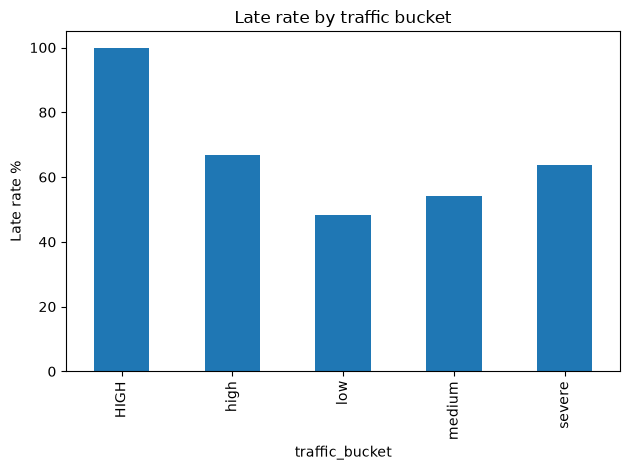

Interpretation: traffic is associated with delay if its groups differ, but distance, restaurant operations, driver supply, and timestamp quality remain alternative explanations.


In [3]:
m = measurable.copy()
m["late_flag"] = (m["delay_min"] > 0).astype(int)
m["distance_band"] = pd.cut(m["distance_km_estimate"], bins=[-1, 3, 7, 100], labels=["0-3 km", "3-7 km", "7+ km"])
m["hour"] = m["created_at"].dt.hour
m["time_band"] = pd.cut(m["hour"], bins=[-1, 6, 11, 15, 19, 24], labels=["night", "morning", "afternoon", "evening", "late night"])
for col in ["traffic_bucket", "weather_bucket", "distance_band", "time_band"]:
    print("\n", col); display(m.groupby(col, observed=False).agg(orders=("order_id","size"), late_rate_pct=("late_flag", lambda x: round(x.mean()*100,2)), median_delay_min=("delay_min","median")).reset_index())
m.groupby("traffic_bucket")["late_flag"].mean().mul(100).plot(kind="bar", title="Late rate by traffic bucket"); plt.ylabel("Late rate %"); plt.tight_layout(); plt.show()
print("Interpretation: traffic is associated with delay if its groups differ, but distance, restaurant operations, driver supply, and timestamp quality remain alternative explanations.")

## Challenge 3 — Customer support view versus system view

In [4]:
print("Ticket categories:"); display(tickets["category"].value_counts().rename_axis("category").reset_index(name="tickets"))
print("Duplicate ticket IDs:", int(tickets["ticket_id"].duplicated().sum()))
ticket_orders = set(tickets["order_id"].dropna())
system = measurable.assign(late_flag=measurable["delay_min"] > 0)
system["has_ticket"] = system["order_id"].isin(ticket_orders)
display(system.groupby("has_ticket").agg(orders=("order_id","size"), late_rate_pct=("late_flag", lambda x: round(x.mean()*100,2)), median_delay_min=("delay_min","median")).reset_index())
print("Tickets add customer language and perceived friction; timestamps show operational timing but not the customer's experience or reason for contact.")

Ticket categories:


,category,tickets
0,late_delivery,38
1,eta_changed,37
2,restaurant_delay,37
3,ready_but_waiting,33
4,status_mismatch,29
5,driver_not_moving,25
6,Late Delivery,1
7,late_delivery,1
8,ETA issue,1


Duplicate ticket IDs: 1


,has_ticket,orders,late_rate_pct,median_delay_min
0,False,654,52.6,0.625653
1,True,100,86.0,12.012413


Tickets add customer language and perceived friction; timestamps show operational timing but not the customer's experience or reason for contact.


## Challenge 4 — Complete Dispatch API ingestion

In [5]:
api_script = ROOT / "src" / "mock_dispatch_api_stdlib.py"
api_proc = subprocess.Popen([sys.executable, str(api_script)], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(1)
import requests
raw_dir = OUT / "class5_raw_dispatch"; raw_dir.mkdir(parents=True, exist_ok=True)
records, page, attempts = [], 1, 0
while True:
    for attempt in range(5):
        response = requests.get("http://127.0.0.1:8000/dispatch/orders", params={"page": page, "page_size": 50}, timeout=10)
        if response.status_code == 200: break
        if response.status_code in (429, 500): time.sleep(0.2 * (attempt + 1)); continue
        response.raise_for_status()
    response.raise_for_status(); payload = response.json()
    (raw_dir / f"page_{page:03d}.json").write_text(json.dumps(payload, indent=2), encoding="utf-8")
    records.extend(payload["data"]); attempts += 1
    if not payload["has_more"]: total = payload["total_records"]; break
    page += 1
print({"pages_saved": page, "records_retrieved": len(records), "api_reported_total": total, "complete": len(records) == total})
api_proc.terminate()

{'pages_saved': 32, 'records_retrieved': 1600, 'api_reported_total': 1600, 'complete': True}


## Challenge 5 — Can we attribute the delay?

In [6]:
flat = [{"driver_id": d["driver_id"], **e} for d in driver_events for e in d["events"]]
driver_events_df = pd.DataFrame(flat)
display(driver_events_df["type"].value_counts().rename_axis("event_type").reset_index(name="events"))
expected = ["assigned", "driver_assigned", "pickup", "picked_up", "delivery", "delivered", "driver_arrived_at_restaurant"]
print("Observed event types:", sorted(driver_events_df["type"].dropna().unique().tolist()))
print("Explicit restaurant-arrival event present:", "driver_arrived_at_restaurant" in set(driver_events_df["type"]))
print("Conclusion: assignment, pickup, and delivery are observed only where their event types exist; driver arrival at the restaurant is not reliably observed, so any arrival time would be inferred from GPS or pickup timing and should not be treated as authoritative.")

,event_type,events
0,gps_ping,5371
1,assigned,1600
2,picked_up,1532
3,delivered,1532


Observed event types: ['assigned', 'delivered', 'gps_ping', 'picked_up']
Explicit restaurant-arrival event present: False
Conclusion: assignment, pickup, and delivery are observed only where their event types exist; driver arrival at the restaurant is not reliably observed, so any arrival time would be inferred from GPS or pickup timing and should not be treated as authoritative.


## Final synthesis

The data supports a measurable late-delivery problem and shows operational associations, but it does not establish causation. The validation warnings—duplicates, missing timestamps, chronology defects, and missing explicit restaurant-arrival events—should be resolved or disclosed before training an AI predictor. The next instrumentation priority is an explicit driver-arrived-at-restaurant event plus consistent lifecycle timestamps.